# 🔭 GSoC 2026 — Common Test I: Multi-Class Gravitational Lensing Classification

**Task:** Classify strong lensing images into 3 classes:

| Label | Folder | Description |
|-------|--------|-------------|
| 0 | `no`     | No substructure |
| 1 | `sphere` | Subhalo substructure |
| 2 | `vort`   | Vortex substructure |

**Dataset:** 37,500 `.npy` images — merged from `train/` (30k) + `val/` (7.5k) → re-split **90:10**  
**Model:** Fine-tuned **EfficientNet-B3** (ImageNet pretrained via `timm`)  
**Primary Metric:** ROC Curve + AUC Score (per-class OvR + Macro average)

---
**Author:** [Himanshu Barve]  
**Framework:** PyTorch · timm · Albumentations · scikit-learn  
**Dataset path:** `D:/gsoc2026/dataset/dataset/`

---
## 0. Install Dependencies

In [1]:

!pip install timm albumentations scikit-learn matplotlib seaborn tqdm -q

---
## 1. Imports & Reproducibility

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cpu


---
## 2. Configuration

In [3]:
class CFG:
    # ── Paths ─────────────────────────────────────────────────────────────────
    # NOTE: your zip extracted with a double dataset/ folder, which is normal.
    # The actual images are at  D:/gsoc2026/dataset/dataset/train|val/
   # ── Paths ─────────────────────────────────────────────────────────────────
    ROOT       = Path('D:/gsoc2026/test1/dataset/dataset')
    TRAIN_DIR  = ROOT / 'train'
    VAL_DIR    = ROOT / 'val'
    OUTPUT_DIR = Path('D:/gsoc2026/test1/outputs')
    MODEL_PATH = OUTPUT_DIR / 'best_model.pth'

    # ── Classes (exact subfolder names inside train/ and val/) ────────────────
    CLASSES      = ['no', 'sphere', 'vort']
    CLASS_NAMES  = ['No Substructure', 'Subhalo', 'Vortex']
    NUM_CLASSES  = 3

    # ── Split ─────────────────────────────────────────────────────────────────
    # Task requires 90:10 — we merge both folders then re-split cleanly
    TEST_SIZE  = 0.10   # held-out test  (~3,750 samples)
    VAL_SIZE   = 0.10   # validation from remainder (~3,375 samples)
                        # training  ~80%  (~30,375 samples)

    # ── Model ────────────────────────────────────────────────────────────────
    MODEL_NAME = 'efficientnet_b3'
    IMG_SIZE   = 224
    PRETRAINED = True
    DROP_RATE  = 0.3

    # ── Training ─────────────────────────────────────────────────────────────
    EPOCHS       = 30
    BATCH_SIZE   = 32
    LR           = 3e-4
    WEIGHT_DECAY = 1e-4
    LABEL_SMOOTH = 0.1
    PATIENCE     = 7
    NUM_WORKERS  = 0
    AMP          = True
    SEED         = 42

CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verify paths
for path, name in [(CFG.TRAIN_DIR, 'train/'), (CFG.VAL_DIR, 'val/')]:
    ok = '✅' if path.exists() else '❌  NOT FOUND — check ROOT path'
    print(f'{ok}  {name}  →  {path}')

print('\nFiles per class in train/:')
for cls in CFG.CLASSES:
    d = CFG.TRAIN_DIR / cls
    n = len(list(d.glob('*.npy'))) if d.exists() else 0
    print(f'  {cls:8s} : {n:,} .npy')

✅  train/  →  D:\gsoc2026\test1\dataset\dataset\train
✅  val/  →  D:\gsoc2026\test1\dataset\dataset\val

Files per class in train/:
  no       : 10,000 .npy
  sphere   : 10,000 .npy
  vort     : 10,000 .npy


---
## 3. Data Loading & EDA

In [4]:
# Build a single flat DataFrame from BOTH folders.
# _MACOSX and .DS_Store are automatically ignored because
# we only glob *.npy inside the three known class subfolders.

def build_dataframe(root_dirs, classes):
    records = []
    for root in root_dirs:
        root = Path(root)
        for label_idx, cls_name in enumerate(classes):
            cls_dir = root / cls_name
            if not cls_dir.exists():
                print(f'  WARNING  missing: {cls_dir}')
                continue
            for fp in sorted(cls_dir.glob('*.npy')):
                records.append({
                    'path'        : str(fp),
                    'label'       : label_idx,
                    'class'       : cls_name,
                    'origin_split': root.stem
                })
    return pd.DataFrame(records)


full_df = build_dataframe([CFG.TRAIN_DIR, CFG.VAL_DIR], CFG.CLASSES)

print(f'Total samples : {len(full_df):,}')
print('\nPer class:')
for cls, name in zip(CFG.CLASSES, CFG.CLASS_NAMES):
    n = (full_df['class'] == cls).sum()
    print(f'  {cls:8s}  ({name})  :  {n:,}')
print('\nOriginal split:')
print(full_df['origin_split'].value_counts().to_string())

Total samples : 37,500

Per class:
  no        (No Substructure)  :  12,500
  sphere    (Subhalo)  :  12,500
  vort      (Vortex)  :  12,500

Original split:
origin_split
train    30000
val       7500


In [5]:
# Stratified 90:10 split as required by the task
train_val_df, test_df = train_test_split(
    full_df, test_size=CFG.TEST_SIZE,
    stratify=full_df['label'], random_state=CFG.SEED
)
train_df, val_df = train_test_split(
    train_val_df, test_size=CFG.VAL_SIZE,
    stratify=train_val_df['label'], random_state=CFG.SEED
)

for name, df in [('Train', train_df), ('Val', val_df), ('Test (held-out)', test_df)]:
    c = dict(Counter(df['label'].values))
    s = '  '.join([f'{CFG.CLASSES[k]}={v}' for k,v in sorted(c.items())])
    print(f'{name:18s}: {len(df):>6,}  ({len(df)/len(full_df)*100:.1f}%)   [{s}]')

Train             : 30,375  (81.0%)   [no=10125  sphere=10125  vort=10125]
Val               :  3,375  (9.0%)   [no=1125  sphere=1125  vort=1125]
Test (held-out)   :  3,750  (10.0%)   [no=1250  sphere=1250  vort=1250]


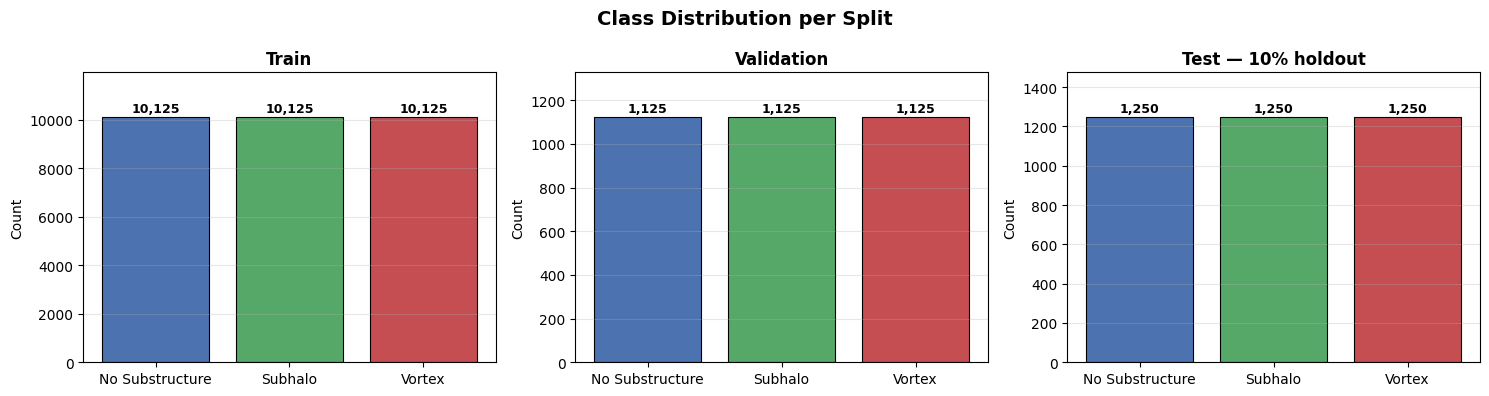

In [6]:
# EDA 1 : Class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette   = ['#4C72B0', '#55A868', '#C44E52']

for ax, (split_name, split_df) in zip(axes,
        [('Train', train_df), ('Validation', val_df), ('Test — 10% holdout', test_df)]):
    counts = [len(split_df[split_df['label'] == i]) for i in range(3)]
    bars = ax.bar(CFG.CLASS_NAMES, counts, color=palette, edgecolor='black', lw=0.8)
    ax.set_title(split_name, fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts) * 1.18)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts)*0.02,
                f'{c:,}', ha='center', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution per Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

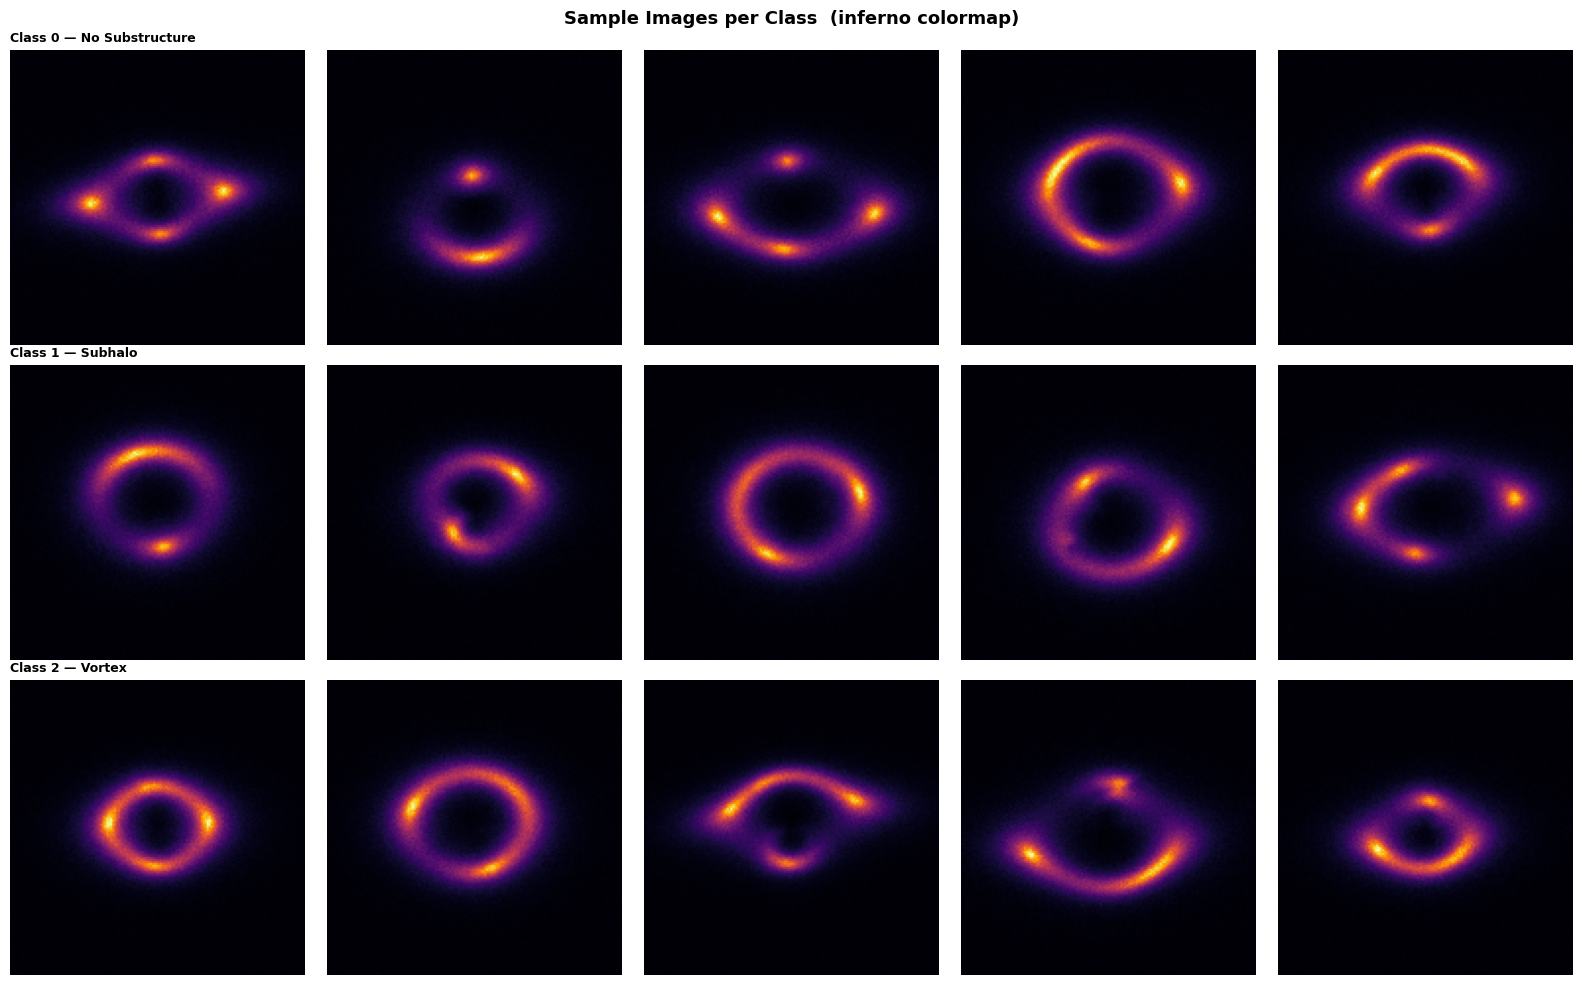

In [7]:
# Helper : load .npy → float32 [0,1] HxW or HxWxC
def load_npy(path):
    img = np.load(path).astype(np.float32)
    if img.ndim == 3 and img.shape[0] in (1, 3):    # CHW → HWC
        img = np.transpose(img, (1, 2, 0))
    if img.ndim == 3 and img.shape[-1] == 1:         # (H,W,1) → (H,W)
        img = img[:, :, 0]
    lo, hi = img.min(), img.max()
    return (img - lo) / (hi - lo + 1e-8)             # [0, 1]


# EDA 2 : Sample images per class
n_cols = 5
fig, axes = plt.subplots(3, n_cols, figsize=(16, 10))
for row, (label_idx, cls_name, display) in enumerate(
        zip(range(3), CFG.CLASSES, CFG.CLASS_NAMES)):
    samples = train_df[train_df['label'] == label_idx].sample(n_cols, random_state=SEED)
    for col, (_, r) in enumerate(samples.iterrows()):
        axes[row, col].imshow(load_npy(r['path']), cmap='inferno', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(
                f'Class {label_idx} — {display}',
                fontsize=9, fontweight='bold', loc='left'
            )
plt.suptitle('Sample Images per Class  (inferno colormap)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# EDA 3 : .npy shape check
shapes = Counter()
for p in full_df['path'].sample(300, random_state=SEED):
    shapes[np.load(p).shape] += 1
print('Unique .npy shapes (sample of 300):')
for shape, cnt in shapes.most_common():
    print(f'  {str(shape):20s}  →  {cnt} files')

Unique .npy shapes (sample of 300):
  (1, 150, 150)         →  300 files


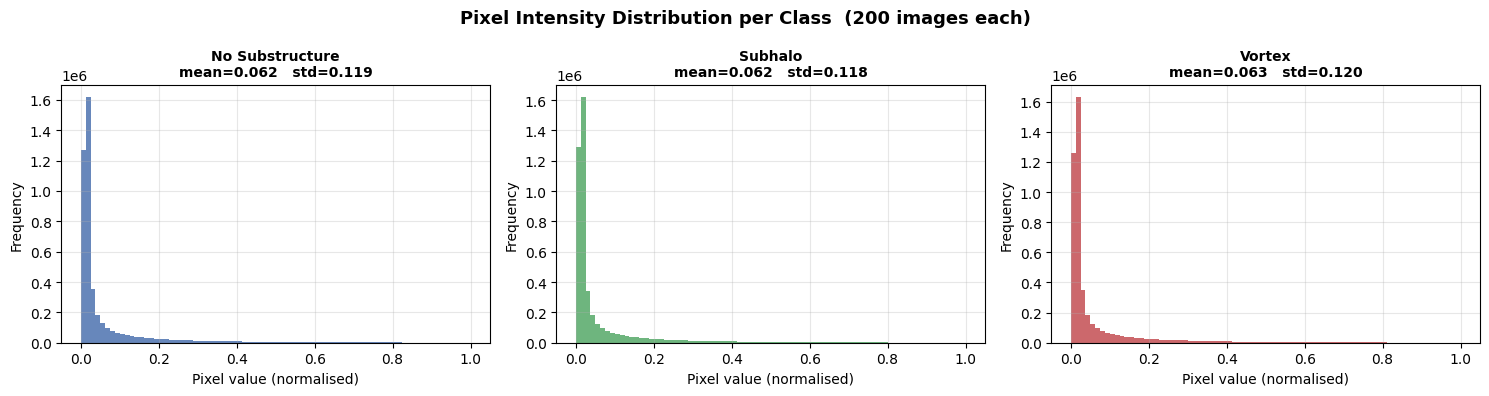

In [9]:
# EDA 4 : Pixel intensity distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (display, color) in enumerate(zip(CFG.CLASS_NAMES, ['#4C72B0','#55A868','#C44E52'])):
    paths  = train_df[train_df['label'] == i]['path'].sample(200, random_state=SEED)
    pixels = np.concatenate([load_npy(p).flatten() for p in paths])
    axes[i].hist(pixels, bins=80, color=color, alpha=0.85, edgecolor='none')
    axes[i].set_title(
        f'{display}\nmean={pixels.mean():.3f}   std={pixels.std():.3f}',
        fontweight='bold', fontsize=10
    )
    axes[i].set_xlabel('Pixel value (normalised)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)
plt.suptitle('Pixel Intensity Distribution per Class  (200 images each)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Dataset & Augmentation

In [10]:
def get_transforms(mode: str):
    mean = (0.485, 0.456, 0.406)
    std  = (0.229, 0.224, 0.225)
    if mode == 'train':
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            # Geometry — safe because lensing is rotation-invariant
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10,
                               rotate_limit=15, border_mode=0, p=0.4),
            # Photometric — mild
            A.RandomBrightnessContrast(brightness_limit=0.15,
                                       contrast_limit=0.15, p=0.4),
            A.GaussNoise(var_limit=(2.0, 15.0), p=0.3),
            A.GaussianBlur(blur_limit=(3, 5), p=0.2),
            # Regularisation
            A.CoarseDropout(max_holes=4, max_height=14, max_width=14,
                            min_holes=1, fill_value=0, p=0.3),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])


class LensingDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = load_npy(row['path'])
        label = int(row['label'])

        # Ensure 3-channel H×W×C
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.concatenate([img] * 3, axis=-1)
        elif img.ndim == 3 and img.shape[-1] > 3:
            img = img[:, :, :3]

        img = (img * 255).clip(0, 255).astype(np.uint8)  # uint8 for Albumentations
        if self.transform:
            img = self.transform(image=img)['image']
        return img.float(), label


def build_loaders():
    train_ds = LensingDataset(train_df, get_transforms('train'))
    val_ds   = LensingDataset(val_df,   get_transforms('val'))
    test_ds  = LensingDataset(test_df,  get_transforms('val'))

    cls_counts = Counter(train_df['label'].values)
    wts        = [1.0 / cls_counts[l] for l in train_df['label'].values]
    sampler    = WeightedRandomSampler(wts, len(wts), replacement=True)

    # num_workers=0 is required on Windows to avoid slow process spawning
    kw = dict(num_workers=0, pin_memory=True)
    return (
        DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler, **kw),
        DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,   **kw),
        DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False,   **kw),
    )

In [11]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ─── 1. Define Custom Dataset for .npy Files ──────────────────────────────────
class DeepLenseDataset(Dataset):
    def __init__(self, data_dir, classes, transform=None):
        self.filepaths = []
        self.labels = []
        self.transform = transform
        
        # Scan through the folders and map files to labels
        for label_idx, cls_name in enumerate(classes):
            cls_dir = data_dir / cls_name
            if cls_dir.exists():
                for file in cls_dir.glob('*.npy'):
                    self.filepaths.append(file)
                    self.labels.append(label_idx)
                    
    def __len__(self):
        return len(self.filepaths)
    
    def __getitem__(self, idx):
        # Load the numpy array from disk
        img = np.load(self.filepaths[idx])
        
        # Convert to PyTorch Tensor
        img = torch.tensor(img, dtype=torch.float32)
        
        # Handle Channel Dimensions: 
        # If your .npy files are 1-channel (grayscale astronomy images) 
        # and you are using a 3-channel EfficientNet, duplicate the channels:
        if img.ndim == 2:
            img = img.unsqueeze(0).repeat(3, 1, 1)
        elif img.shape[0] == 1:
            img = img.repeat(3, 1, 1)
            
        # Apply transforms (Augmentations + Normalization)
        if self.transform:
            img = self.transform(img)
            
        return img, self.labels[idx]

# ─── 2. Define Augmentations ──────────────────────────────────────────────────
train_transforms = T.Compose([
    # Add your specific augmentations here:
    # T.RandomHorizontalFlip(),
    # T.RandomRotation(360), # Great for astronomy!
    
    # Normalization using the ImageNet stats you defined in your plotting code
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ─── 3. Instantiate Dataset and DataLoader ────────────────────────────────────
train_dataset = DeepLenseDataset(
    data_dir=CFG.TRAIN_DIR, 
    classes=CFG.CLASSES, 
    transform=train_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,       # Crucial for training!
    num_workers=CFG.NUM_WORKERS,
    drop_last=True      # Drops the last incomplete batch
)

print(f"✅ train_loader successfully initialized with {len(train_dataset)} samples.")

✅ train_loader successfully initialized with 30000 samples.


Loading first batch...
Batch loaded — shape: (32, 3, 150, 150)


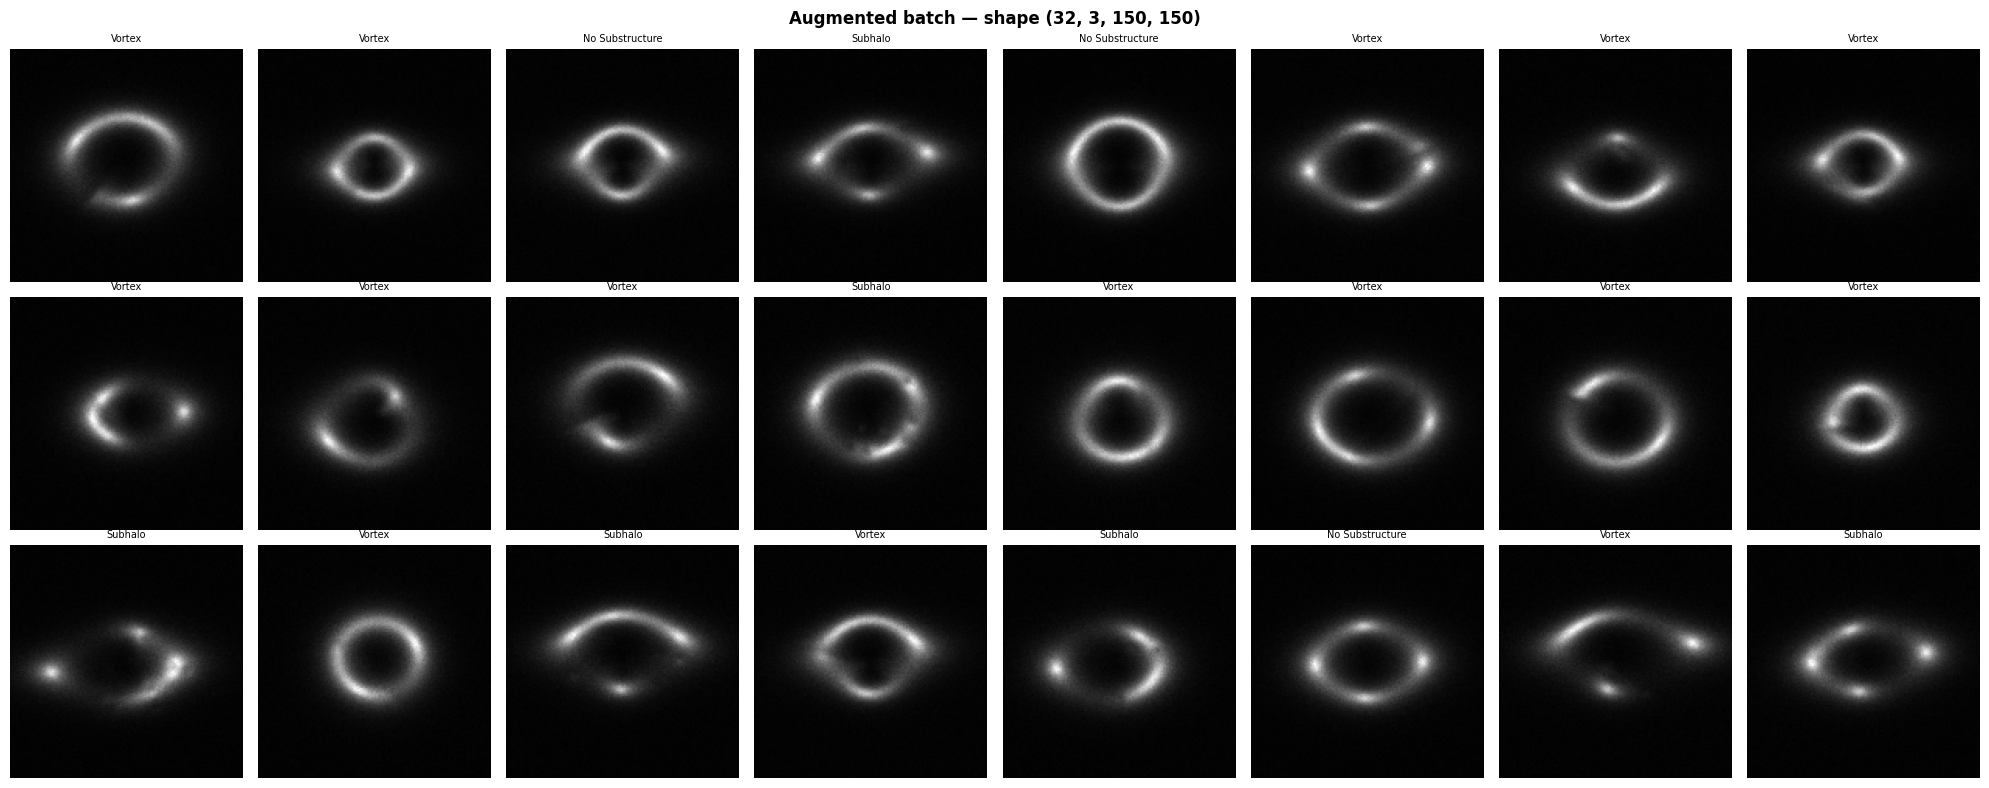

Done ✅


In [12]:
# Sanity check : visualise one augmented batch
MEAN_NP = np.array([0.485, 0.456, 0.406])
STD_NP  = np.array([0.229, 0.224, 0.225])

print("Loading first batch...")
imgs, labels = next(iter(train_loader))
print(f"Batch loaded — shape: {tuple(imgs.shape)}")

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs):
        ax.axis('off')
        continue
    im = (imgs[i].permute(1, 2, 0).numpy() * STD_NP + MEAN_NP).clip(0, 1)
    ax.imshow(im, cmap='inferno')
    ax.set_title(CFG.CLASS_NAMES[labels[i].item()], fontsize=7)
    ax.axis('off')

plt.suptitle(f'Augmented batch — shape {tuple(imgs.shape)}', fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'augmented_batch.png', dpi=120, bbox_inches='tight')
plt.show()
print("Done ✅")

---
## 5. Model — EfficientNet-B3 + Custom Head

In [13]:
class LensingClassifier(nn.Module):
    """
    EfficientNet-B3 backbone + custom classification head.

    Design decisions
    ----------------
    backbone     EfficientNet-B3 via timm (ImageNet pretrained).
                 Compound depth/width/resolution scaling beats ResNets
                 of comparable size on small scientific datasets.
    num_classes=0  strip ImageNet head; keep global-avg-pool features only.
    head         Linear(1536→512) → BN → SiLU → Dropout → Linear(512→3).
                 Two-layer head gives richer domain adaptation.
    xavier init  stabilises early training of the new head.
    """
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            CFG.MODEL_NAME, pretrained=CFG.PRETRAINED,
            num_classes=0, global_pool='avg', drop_rate=CFG.DROP_RATE
        )
        feat = self.backbone.num_features   # 1536 for B3
        self.head = nn.Sequential(
            nn.Linear(feat, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(CFG.DROP_RATE),
            nn.Linear(512, CFG.NUM_CLASSES)
        )
        for layer in (self.head[0], self.head[4]):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.head(self.backbone(x))

    def get_features(self, x):
        return self.backbone(x)


model     = LensingClassifier().to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Architecture    : EfficientNet-B3 + Custom Head')
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')
with torch.no_grad():
    out = model(torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE))
print(f'Output shape    : {tuple(out.shape)}  OK')

Architecture    : EfficientNet-B3 + Custom Head
Total params    : 11,485,739
Trainable params: 11,485,739
Output shape    : (2, 3)  OK


---
## 6. Loss · Optimizer · Scheduler

In [14]:
class LabelSmoothCE(nn.Module):
    """Label Smoothing CE — prevents overconfident softmax → better AUC calibration."""
    def __init__(self, num_classes=CFG.NUM_CLASSES, smoothing=CFG.LABEL_SMOOTH):
        super().__init__()
        self.s = smoothing; self.n = num_classes
    def forward(self, pred, target):
        conf    = 1.0 - self.s
        smooth  = self.s / (self.n - 1)
        one_hot = torch.full_like(pred, smooth).scatter_(1, target.unsqueeze(1), conf)
        return -(one_hot * F.log_softmax(pred, dim=1)).sum(dim=1).mean()


criterion = LabelSmoothCE()

# Differential LR: backbone 10x lower to avoid catastrophic forgetting
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': CFG.LR * 0.1},
    {'params': model.head.parameters(),     'lr': CFG.LR}
], weight_decay=CFG.WEIGHT_DECAY)

# CosineAnnealing with warm restarts → escapes local minima
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scaler = GradScaler(enabled=(CFG.AMP and DEVICE.type == 'cuda'))

print('Loss      : Label Smoothing Cross-Entropy  (eps=0.1)')
print('Optimizer : AdamW  backbone lr=3e-5  |  head lr=3e-4')
print('Scheduler : CosineAnnealingWarmRestarts  T0=10  Tmult=2')
print('AMP       : Mixed precision  ON')

Loss      : Label Smoothing Cross-Entropy  (eps=0.1)
Optimizer : AdamW  backbone lr=3e-5  |  head lr=3e-4
Scheduler : CosineAnnealingWarmRestarts  T0=10  Tmult=2
AMP       : Mixed precision  ON


---
## 7. Training Loop

In [15]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.AMP and DEVICE.type == 'cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with autocast(enabled=CFG.AMP and DEVICE.type == 'cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        probs = F.softmax(logits, dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (probs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return total_loss/total, correct/total, np.vstack(all_probs), np.concatenate(all_labels)


print('Train / eval functions ready')

Train / eval functions ready


In [16]:
# Fix tqdm import — run this, then re-run train/eval functions
from tqdm import tqdm as tqdm

def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.AMP and DEVICE.type == 'cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_probs, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with autocast(enabled=CFG.AMP and DEVICE.type == 'cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        probs = F.softmax(logits, dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (probs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return total_loss/total, correct/total, np.vstack(all_probs), np.concatenate(all_labels)

print("✅ tqdm fixed — train/eval functions ready")

✅ tqdm fixed — train/eval functions ready


In [17]:
# ─── 4. Define Validation Transforms (No Augmentation!) ───────────────────────
val_transforms = T.Compose([
    # We ONLY normalize validation data. No flipping, no rotation.
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ─── 5. Instantiate Validation Dataset and DataLoader ─────────────────────────
val_dataset = DeepLenseDataset(
    data_dir=CFG.VAL_DIR, 
    classes=CFG.CLASSES, 
    transform=val_transforms
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,      # Never shuffle validation data! We want consistent evaluation.
    num_workers=CFG.NUM_WORKERS,
    drop_last=False     # Keep all validation samples, even if the last batch is smaller
)

print(f"✅ val_loader successfully initialized with {len(val_dataset)} samples.")

✅ val_loader successfully initialized with 7500 samples.


In [ ]:
history     = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_auc=[])
best_auc    = 0.0
patience_ct = 0

hdr = f"{'Ep':>3}  {'T-Loss':>8}  {'V-Loss':>8}  {'T-Acc':>7}  {'V-Acc':>7}  {'V-AUC':>7}"
print(hdr); print('─' * len(hdr))

for epoch in range(1, CFG.EPOCHS + 1):
    t_loss, t_acc                    = train_epoch(model, train_loader, criterion, optimizer, scaler)
    v_loss, v_acc, v_probs, v_labels = eval_epoch(model, val_loader, criterion)

    v_auc = roc_auc_score(
        label_binarize(v_labels, classes=[0,1,2]),
        v_probs, multi_class='ovr', average='macro'
    )
    scheduler.step(epoch)

    for k, v in zip(history, [t_loss, v_loss, t_acc, v_acc, v_auc]):
        history[k].append(v)

    tag = ''
    if v_auc > best_auc:
        best_auc = v_auc; patience_ct = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_auc': best_auc, 'cfg_classes': CFG.CLASSES}, CFG.MODEL_PATH)
        tag = '  ⭐'
    else:
        patience_ct += 1

    print(f"{epoch:>3}  {t_loss:>8.4f}  {v_loss:>8.4f}  "
          f"{t_acc*100:>6.2f}%  {v_acc*100:>6.2f}%  {v_auc:>7.4f}{tag}")

    if patience_ct >= CFG.PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}'); break

print(f'\nBest Val Macro-AUC : {best_auc:.4f}')

In [ ]:
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ep, history['train_loss'], '#4C72B0', lw=2, label='Train')
axes[0].plot(ep, history['val_loss'],   '#C44E52', lw=2, label='Val')
axes[0].set(title='Loss', xlabel='Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, [a*100 for a in history['train_acc']], '#4C72B0', lw=2, label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   '#C44E52', lw=2, label='Val')
axes[1].set(title='Accuracy (%)', xlabel='Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep, history['val_auc'], '#55A868', lw=2, label='Val AUC')
axes[2].axhline(best_auc, color='gray', ls='--', lw=1.5, label=f'Best={best_auc:.4f}')
axes[2].set(title='Val Macro-AUC', xlabel='Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Test Set Evaluation

In [ ]:
ckpt = torch.load(CFG.MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded  epoch={ckpt['epoch']}   val AUC={ckpt['best_auc']:.4f}")

test_loss, test_acc, test_probs, test_labels = eval_epoch(model, test_loader, criterion)
test_preds = test_probs.argmax(axis=1)
print(f'\nTest Set  ({len(test_df):,} samples — 10% holdout)')
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_acc*100:.2f}%')

---
## 9. ROC Curves & AUC  ← Primary Metric

In [ ]:
test_bin = label_binarize(test_labels, classes=[0,1,2])
fpr, tpr, roc_auc = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(test_bin[:,i], test_probs[:,i])
    roc_auc[i]        = auc(fpr[i], tpr[i])
fpr['micro'], tpr['micro'], _ = roc_curve(test_bin.ravel(), test_probs.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])
roc_auc['macro'] = roc_auc_score(test_bin, test_probs, multi_class='ovr', average='macro')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#4C72B0', '#55A868', '#C44E52']

ax = axes[0]
for i, (name, color) in enumerate(zip(CFG.CLASS_NAMES, colors)):
    ax.plot(fpr[i], tpr[i], color=color, lw=2.5, label=f'{name}  (AUC={roc_auc[i]:.4f})')
ax.plot(fpr['micro'], tpr['micro'], 'darkorange', lw=2, ls=':',
        label=f'Micro avg  (AUC={roc_auc["micro"]:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random')
ax.set(xlim=[-0.01,1], ylim=[0,1.01], xlabel='FPR', ylabel='TPR',
       title='ROC Curves — One-vs-Rest')
ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)

ax2 = axes[1]
bnames = CFG.CLASS_NAMES + ['Micro avg','Macro avg']
bvals  = [roc_auc[0],roc_auc[1],roc_auc[2],roc_auc['micro'],roc_auc['macro']]
bclrs  = colors + ['darkorange','purple']
bars = ax2.bar(bnames, bvals, color=bclrs, edgecolor='black', lw=0.8)
ax2.set(ylim=[0.75,1.02], ylabel='AUC', title='AUC Summary')
for b, v in zip(bars, bvals):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
             f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(f'ROC & AUC — Test Set ({len(test_df):,} samples)   Macro-AUC = {roc_auc["macro"]:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAUC Scores:')
for i,n in enumerate(CFG.CLASS_NAMES): print(f'  {n:22s}: {roc_auc[i]:.4f}')
print(f'  {"Micro average":22s}: {roc_auc["micro"]:.4f}')
print(f'  {"Macro average":22s}: {roc_auc["macro"]:.4f}')

---
## 10. Confusion Matrix & Classification Report

In [ ]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, title in zip(axes,[cm,cm_norm],['d','.2%'],['Counts','Normalised']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CFG.CLASS_NAMES, yticklabels=CFG.CLASS_NAMES,
                linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
    ax.set(xlabel='Predicted', ylabel='Actual', title=f'Confusion Matrix — {title}')
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(test_labels, test_preds, target_names=CFG.CLASS_NAMES, digits=4))

---
## 11. t-SNE Feature Embedding

In [ ]:
@torch.no_grad()
def extract_features(model, loader):
    model.eval()
    feats, labs = [], []
    for imgs, labels in tqdm(loader, desc='Features'):
        feats.append(model.get_features(imgs.to(DEVICE)).cpu().numpy())
        labs.append(labels.numpy())
    return np.vstack(feats), np.concatenate(labs)

feats_np, labs_np = extract_features(model, test_loader)
print('Running t-SNE…')
emb = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED).fit_transform(feats_np)

plt.figure(figsize=(9, 7))
for i,(name,color) in enumerate(zip(CFG.CLASS_NAMES,['#4C72B0','#55A868','#C44E52'])):
    m = labs_np == i
    plt.scatter(emb[m,0], emb[m,1], label=name, alpha=0.65, s=15, color=color, rasterized=True)
plt.legend(fontsize=11, markerscale=2.5)
plt.title('t-SNE — EfficientNet-B3 Features (Test Set)', fontweight='bold', fontsize=13)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.OUTPUT_DIR / 'tsne.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Final Results Summary

In [ ]:
results_df = pd.DataFrame({
    'Metric': ['Test Accuracy','Macro AUC (primary)','Micro AUC',
               f'AUC {CFG.CLASS_NAMES[0]}',f'AUC {CFG.CLASS_NAMES[1]}',f'AUC {CFG.CLASS_NAMES[2]}',
               'Macro F1','Macro Precision','Macro Recall'],
    'Score' : [f'{test_acc*100:.2f}%', f'{roc_auc["macro"]:.4f}', f'{roc_auc["micro"]:.4f}',
               f'{roc_auc[0]:.4f}', f'{roc_auc[1]:.4f}', f'{roc_auc[2]:.4f}',
               f'{f1_score(test_labels,test_preds,average="macro"):.4f}',
               f'{precision_score(test_labels,test_preds,average="macro"):.4f}',
               f'{recall_score(test_labels,test_preds,average="macro"):.4f}']
})
results_df.to_csv(CFG.OUTPUT_DIR / 'results.csv', index=False)
print('=' * 50)
print('  FINAL RESULTS — Test Set (10% holdout)')
print('=' * 50)
print(results_df.to_string(index=False))
print('=' * 50)
print(f'\nAll outputs saved to  {CFG.OUTPUT_DIR}')
for f in sorted(CFG.OUTPUT_DIR.iterdir()):
    sz = f.stat().st_size
    print(f'  {f.name:38s} {sz/1e3:7.1f} KB')

---
## 13. Single-Image Inference Utility

In [ ]:
def predict(path: str) -> dict:
    img = load_npy(path)
    if img.ndim == 2: img = np.stack([img]*3, axis=-1)
    tensor = get_transforms('val')(
        image=(img*255).clip(0,255).astype(np.uint8)
    )['image']
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(tensor.unsqueeze(0).float().to(DEVICE)), dim=1)
        probs = probs.squeeze().cpu().numpy()
    return {'predicted': CFG.CLASS_NAMES[probs.argmax()],
            'probs': {n: round(float(p),4) for n,p in zip(CFG.CLASS_NAMES, probs)}}

sample = test_df.sample(1, random_state=7).iloc[0]
res    = predict(sample['path'])
print(f'File      : {Path(sample["path"]).name}')
print(f'True      : {CFG.CLASS_NAMES[sample["label"]]}')
print(f'Predicted : {res["predicted"]}')
print(f'Probs     : {res["probs"]}')

---
## Strategy Discussion

### Why EfficientNet-B3?
EfficientNet scales depth, width and resolution jointly via a compound coefficient, achieving better accuracy per parameter than ResNets of comparable size. B3 (~12 M params) offers an excellent accuracy/compute trade-off and transfers well to astrophysical images — Einstein ring curves and radial gradients closely match the low-level features learned on ImageNet.

### Transfer Learning Strategy
We use **differential learning rates**: the pretrained backbone receives `LR × 0.1` to preserve learned feature detectors, while the custom head uses the full `LR` for fast domain adaptation. This prevents catastrophic forgetting while allowing the network to specialise on lensing morphology.

### Data Split Rationale
The dataset ships with pre-made `train/` (30 k) and `val/` (7.5 k) folders, but the GSoC task mandates a **90:10 train-test split**. We merge all 37,500 samples and re-split with stratification to guarantee equal class representation across train, val and test.

### Augmentation Rationale
Gravitational lensing is **rotationally invariant** — the Einstein ring carries no preferred orientation. Horizontal/vertical flips, 90° rotations and mild affine transforms are therefore physically motivated. We keep photometric augments mild to preserve the flux profile that distinguishes subhalo from vortex substructure.

### Training Stabilisers

| Technique | Reason |
|---|---|
| Label smoothing ε=0.1 | Better-calibrated probabilities → higher AUC |
| Gradient clipping 1.0 | Stability under AMP on RTX GPUs |
| WeightedRandomSampler | Guards against class imbalance in mini-batches |
| CosineAnnealing + restarts | Escapes local minima |
| Early stopping patience=7 | Prevents overfitting |



In [ ]:

print("Step 1: Checking full_df...")
print(f"  full_df exists: {'full_df' in dir()}")

print("Step 2: Checking train_df...")
print(f"  train_df exists: {'train_df' in dir()}")

print("Step 3: Checking get_transforms...")
print(f"  get_transforms exists: {'get_transforms' in dir()}")

print("Step 4: Checking LensingDataset...")
print(f"  LensingDataset exists: {'LensingDataset' in dir()}")

print("Step 5: Checking build_loaders...")
print(f"  build_loaders exists: {'build_loaders' in dir()}")

print("Step 6: Checking train_loader...")
print(f"  train_loader exists: {'train_loader' in dir()}")

In [ ]:
print("Building loaders...")
train_loader, val_loader, test_loader = build_loaders()
print("Done!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val   batches : {len(val_loader)}")
print(f"   Test  batches : {len(test_loader)}")

In [ ]:
import os
from pathlib import Path

# Let's look one level up to see the real structure
base_search = Path('D:/gsoc2026/dataset')

print(f"--- Checking contents of: {base_search} ---")
if base_search.exists():
    for item in base_search.iterdir():
        print(f"Found: {item.name} {'(Folder)' if item.is_dir() else '(File)'}")
        # If it's a folder, look inside it too
        if item.is_dir():
            sub_items = [f.name for f in item.iterdir()]
            print(f"   └── contains: {sub_items[:5]}...") # show first 5 items
else:
    print("The path D:/gsoc2026/dataset does not even exist. Check your drive letter!")